# Jakarta CRM Complaint Dashboard

### Steps:
1. Library & Setup
2. Data Integration
3. Data Preprocessing
4. Exploratory & Data Analysis (EDA)


---
## **1. Library & Setup**
<a id='library--setup'></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import io
import warnings

warnings.filterwarnings("ignore")

from google.colab import files
import glob
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## **2. Data Integration**
<a id='data-integration'></a>

In [ ]:
# Path dataset
file_2019 = '/content/drive/MyDrive/data-pengaduan-crm-2019.csv'
file_2020 = '/content/drive/MyDrive/data-pengaduan-crm-2020.csv'

# Read dataset
df_2019 = pd.read_csv(file_2019, sep = ";")
df_2020 = pd.read_csv(file_2020, sep = ";")

# Integrate
df_combined = pd.concat([df_2019, df_2020], ignore_index=True)

combined_data = 'jakarta_crm_2019_2020.csv'
df_combined.to_csv(combined_data)

# Download
files.download(combined_data)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_raw = pd.read_csv("/content/jakarta_crm_2019_2020.csv")
df_raw.head()

,Unnamed: 0,trace_number,nama_skpd,kategori,rincian_masalah,status,tanggal_masuk,tanggal_selesai,periode_data,id_laporan,skpd,waktu_masuk,waktu_selesai
0,0,QL001339832,KELURAHAN PEGADUNGAN,SALURAN AIR,"NULL""",COMPLETE,1/1/2019,1/1/2019,201901.0,NaN,NaN,NaN,NaN
1,1,JK2001010019,KELURAHAN KAPUK,BANJIR,LAPORAN BANJIR,COMPLETE,1/1/2019,1/10/2019,201901.0,NaN,NaN,NaN,NaN
2,2,JK2001010017,KELURAHAN KAPUK,BANJIR,LAPORAN BANJIR,COMPLETE,1/1/2019,1/10/2019,201901.0,NaN,NaN,NaN,NaN
3,3,QL001339801,KELURAHAN PEGADUNGAN,SAMPAH,"NULL""",COMPLETE,1/1/2019,1/1/2019,201901.0,NaN,NaN,NaN,NaN
4,4,QL001339800,KELURAHAN PEGADUNGAN,SAMPAH,SAMPAH LINGKUNGAN,COMPLETE,1/1/2019,1/1/2019,201901.0,NaN,NaN,NaN,NaN


---
## **3. Data Preprocessing**
<a id='data-preprocessing'></a>

In [ ]:
df = df_raw.copy()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14991 entries, 0 to 14990
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       14991 non-null  int64  
 1   trace_number     9743 non-null   object 
 2   nama_skpd        9742 non-null   object 
 3   kategori         14989 non-null  object 
 4   rincian_masalah  9591 non-null   object 
 5   status           14838 non-null  object 
 6   tanggal_masuk    9591 non-null   object 
 7   tanggal_selesai  9590 non-null   object 
 8   periode_data     14732 non-null  float64
 9   id_laporan       5247 non-null   object 
 10  skpd             5247 non-null   object 
 11  waktu_masuk      5247 non-null   object 
 12  waktu_selesai    5247 non-null   object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.5+ MB


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
trace_number,5248
nama_skpd,5249
kategori,2
rincian_masalah,5400
status,153
tanggal_masuk,5400
tanggal_selesai,5401
periode_data,259
id_laporan,9744


In [ ]:
# Fill in NaN Rows
df['id_laporan'] = df['trace_number'].fillna(df['id_laporan'])
df['skpd'] = df['nama_skpd'].fillna(df['skpd'])
df['rincian_masalah'] = df['rincian_masalah'].fillna('Tidak Disebutkan')
df['tanggal_masuk'] = pd.to_datetime(df['tanggal_masuk'], errors='coerce').fillna(pd.to_datetime(df['waktu_masuk'], errors='coerce'))
df['tanggal_selesai'] = pd.to_datetime(df['tanggal_selesai'], errors='coerce').fillna( pd.to_datetime(df['waktu_selesai'], errors='coerce'))

# Drop columns
df = df.drop(columns=['trace_number','nama_skpd','waktu_masuk','waktu_selesai','periode_data','Unnamed: 0'])

# Drop missing value
df = df.dropna(subset=['id_laporan','skpd','kategori','status','tanggal_masuk','tanggal_selesai'])

In [ ]:
df.head()

,kategori,rincian_masalah,status,tanggal_masuk,tanggal_selesai,id_laporan,skpd
0,SALURAN AIR,"NULL""",COMPLETE,2019-01-01,2019-01-01,QL001339832,KELURAHAN PEGADUNGAN
1,BANJIR,LAPORAN BANJIR,COMPLETE,2019-01-01,2019-01-10,JK2001010019,KELURAHAN KAPUK
2,BANJIR,LAPORAN BANJIR,COMPLETE,2019-01-01,2019-01-10,JK2001010017,KELURAHAN KAPUK
3,SAMPAH,"NULL""",COMPLETE,2019-01-01,2019-01-01,QL001339801,KELURAHAN PEGADUNGAN
4,SAMPAH,SAMPAH LINGKUNGAN,COMPLETE,2019-01-01,2019-01-01,QL001339800,KELURAHAN PEGADUNGAN


In [ ]:
# Replace "NULL" text with "-"
df['rincian_masalah'] = df['rincian_masalah'].replace(r'^NULL.*$', '-', regex = True)

In [ ]:
# Calculate and Check Response Time
df['response_time'] = (df['tanggal_selesai'] - df['tanggal_masuk']).dt.days

print("Negative response time:", (df['response_time'] < 0).sum(), "\n")
print("Response time stats:")
print(df['response_time'].describe())

Negative response time: 73 

Response time stats:
count    13462.000000
mean         0.291116
std         11.382785
min       -294.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        294.000000
Name: response_time, dtype: float64


In [ ]:
# Drop rows with negative response time
df = df[df['response_time'] >= 0]

print(f"Response time stats (after drop):")
print(df['response_time'].describe())

Response time stats (after drop):
count    13389.000000
mean         0.743969
std          7.598493
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        294.000000
Name: response_time, dtype: float64


In [ ]:
df.head()

,kategori,rincian_masalah,status,tanggal_masuk,tanggal_selesai,id_laporan,skpd,response_time
0,SALURAN AIR,-,COMPLETE,2019-01-01,2019-01-01,QL001339832,KELURAHAN PEGADUNGAN,0
1,BANJIR,LAPORAN BANJIR,COMPLETE,2019-01-01,2019-01-10,JK2001010019,KELURAHAN KAPUK,9
2,BANJIR,LAPORAN BANJIR,COMPLETE,2019-01-01,2019-01-10,JK2001010017,KELURAHAN KAPUK,9
3,SAMPAH,-,COMPLETE,2019-01-01,2019-01-01,QL001339801,KELURAHAN PEGADUNGAN,0
4,SAMPAH,SAMPAH LINGKUNGAN,COMPLETE,2019-01-01,2019-01-01,QL001339800,KELURAHAN PEGADUNGAN,0


In [ ]:
# Standardize text columns (uppercase and remove whitespace)

df['skpd'] = df['skpd'].str.upper().str.strip()
df['kategori'] = df['kategori'].str.upper().str.strip()
df['rincian_masalah'] = df['rincian_masalah'].str.upper().str.strip()
df['status'] = df['status'].str.upper().str.strip()

In [ ]:
df.head()

,kategori,rincian_masalah,status,tanggal_masuk,tanggal_selesai,id_laporan,skpd,response_time
0,SALURAN AIR,-,COMPLETE,2019-01-01,2019-01-01,QL001339832,KELURAHAN PEGADUNGAN,0
1,BANJIR,LAPORAN BANJIR,COMPLETE,2019-01-01,2019-01-10,JK2001010019,KELURAHAN KAPUK,9
2,BANJIR,LAPORAN BANJIR,COMPLETE,2019-01-01,2019-01-10,JK2001010017,KELURAHAN KAPUK,9
3,SAMPAH,-,COMPLETE,2019-01-01,2019-01-01,QL001339801,KELURAHAN PEGADUNGAN,0
4,SAMPAH,SAMPAH LINGKUNGAN,COMPLETE,2019-01-01,2019-01-01,QL001339800,KELURAHAN PEGADUNGAN,0


In [ ]:
df_clean = 'crm_jakarta_cleaned.csv'
df.to_csv(df_clean, index=False)
files.download(df_clean)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## **4. Exploratory & Data Analysis**
<a id='exploratory--data-analysis-eda'></a>

In [ ]:
df_clean = pd.read_csv('crm_jakarta_cleaned.csv', parse_dates=['tanggal_masuk', 'tanggal_selesai'])
df_clean.head()

,kategori,rincian_masalah,status,tanggal_masuk,tanggal_selesai,id_laporan,skpd,response_time
0,SALURAN AIR,-,COMPLETE,2019-01-01,2019-01-01,QL001339832,KELURAHAN PEGADUNGAN,0
1,BANJIR,LAPORAN BANJIR,COMPLETE,2019-01-01,2019-01-10,JK2001010019,KELURAHAN KAPUK,9
2,BANJIR,LAPORAN BANJIR,COMPLETE,2019-01-01,2019-01-10,JK2001010017,KELURAHAN KAPUK,9
3,SAMPAH,-,COMPLETE,2019-01-01,2019-01-01,QL001339801,KELURAHAN PEGADUNGAN,0
4,SAMPAH,SAMPAH LINGKUNGAN,COMPLETE,2019-01-01,2019-01-01,QL001339800,KELURAHAN PEGADUNGAN,0


In [ ]:
print(df_clean.dtypes)

kategori                   object
rincian_masalah            object
status                     object
tanggal_masuk      datetime64[ns]
tanggal_selesai    datetime64[ns]
id_laporan                 object
skpd                       object
response_time               int64
dtype: object


In [ ]:
# Add column "tahun"
df_clean['tahun'] = df_clean['tanggal_masuk'].dt.year.astype(str)

- Top 10

In [ ]:
top_kategori = (df_clean['kategori']
                .value_counts()
                .head(10)
                .reset_index())
top_kategori.columns = ['kategori', 'jumlah']
top_kategori

,kategori,jumlah
0,SAMPAH,6515
1,PELANGGARAN PERDA/PERGUB,2031
2,GANGGUAN KETENTERAMAN DAN KETERTIBAN,843
3,"SALURAN AIR, KALI/SUNGAI",553
4,JEMBATAN PENYEBERANGAN ORANG (JPO) DAN/ATAU HALTE,506
5,POHON,377
6,SALURAN AIR,311
7,BANJIR,284
8,JALAN,197
9,BANTUAN SOSIAL,190


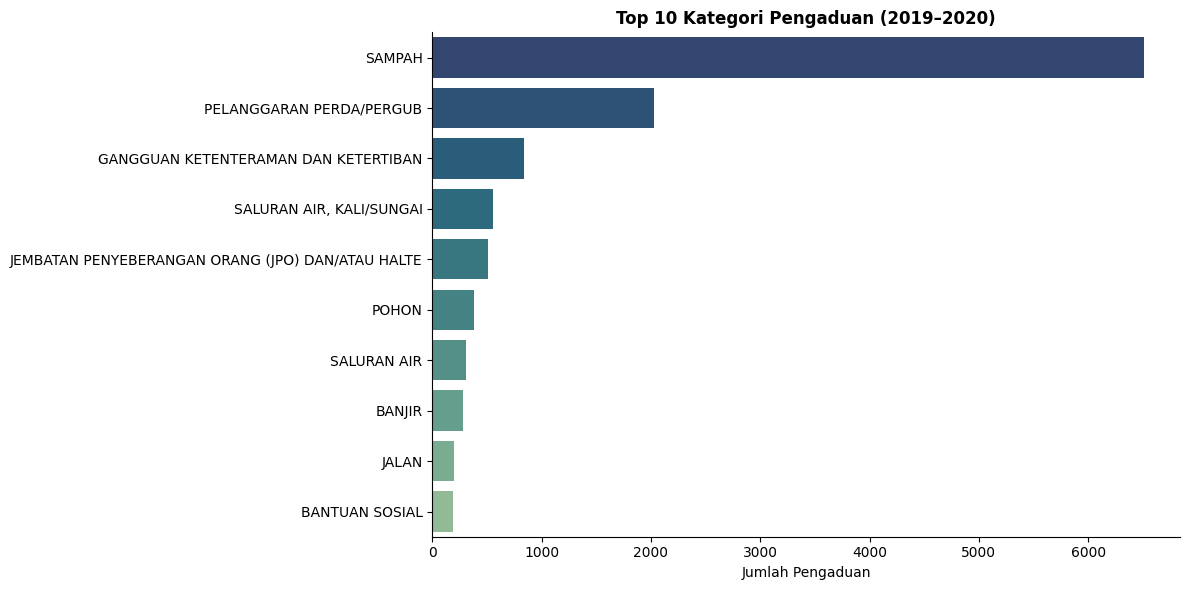

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_kategori, x='jumlah', y='kategori',
            palette='crest_r', hue='kategori', legend=False)
plt.title('Top 10 Kategori Pengaduan (2019–2020)', fontweight='bold')
plt.xlabel('Jumlah Pengaduan')
plt.ylabel('')
sns.despine()
plt.tight_layout()
plt.show()

- Tren Bulanan

In [ ]:
nama_bulan = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

df_clean['nama_bulan'] = df_clean['tanggal_masuk'].dt.month_name()

tren_bulanan = (df_clean.groupby(['tahun', 'nama_bulan']).size().reset_index(name='jumlah'))
tren_bulanan['nama_bulan'] = pd.Categorical(tren_bulanan['nama_bulan'], categories=nama_bulan, ordered=True)
tren_bulanan = tren_bulanan.sort_values(['tahun', 'nama_bulan'])
tren_bulanan

,tahun,nama_bulan,jumlah
4,2019,January,424
3,2019,February,851
7,2019,March,48
0,2019,April,1172
8,2019,May,133
6,2019,June,1393
5,2019,July,1204
1,2019,August,1000
11,2019,September,709
10,2019,October,532


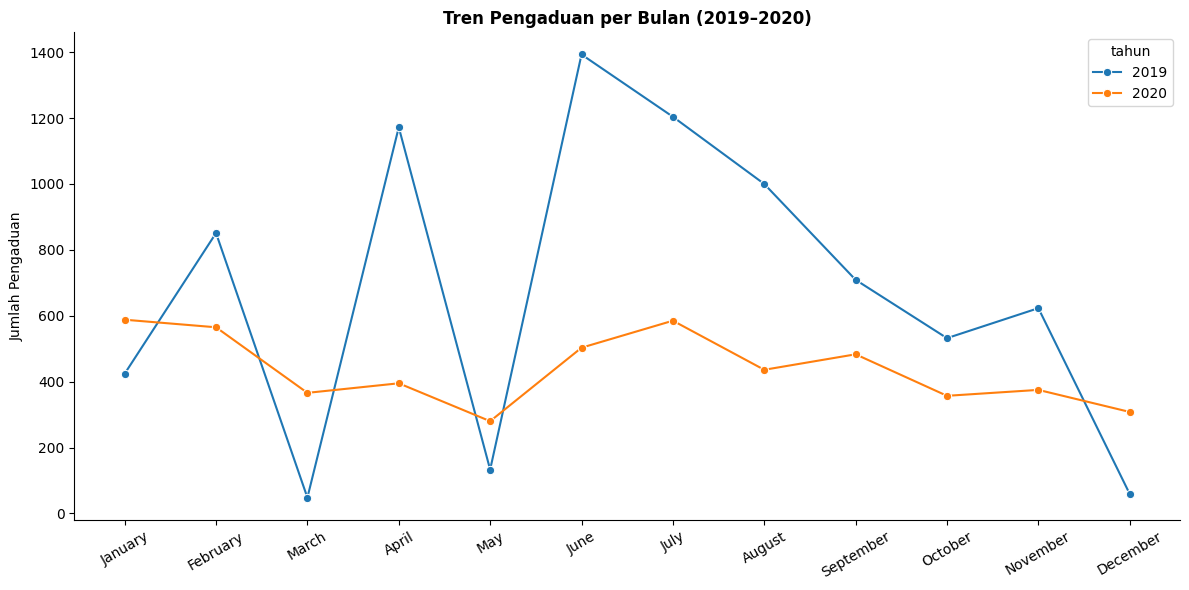

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=tren_bulanan, x='nama_bulan', y='jumlah',
             hue='tahun', marker='o', palette='tab10')
plt.title('Tren Pengaduan per Bulan (2019–2020)', fontweight='bold')
plt.xlabel('')
plt.ylabel('Jumlah Pengaduan')
plt.xticks(rotation=30)
sns.despine()
plt.tight_layout()
plt.show()

- Top 10 SKPD by Volume

In [ ]:
top_skpd = (df_clean['skpd']
            .value_counts()
            .head(10)
            .reset_index())
top_skpd.columns = ['skpd', 'jumlah']
top_skpd

,skpd,jumlah
0,KELURAHAN PAL MERAH,592
1,KELURAHAN GAMBIR,583
2,KELURAHAN TANJUNG DUREN SELATAN,575
3,KELURAHAN SLIPI,497
4,KELURAHAN GROGOL,477
5,KELURAHAN SEMANAN,405
6,KELURAHAN PEGADUNGAN,375
7,KELURAHAN KEMANGGISAN,372
8,KELURAHAN PETAMBURAN,362
9,KELURAHAN TOMANG,332


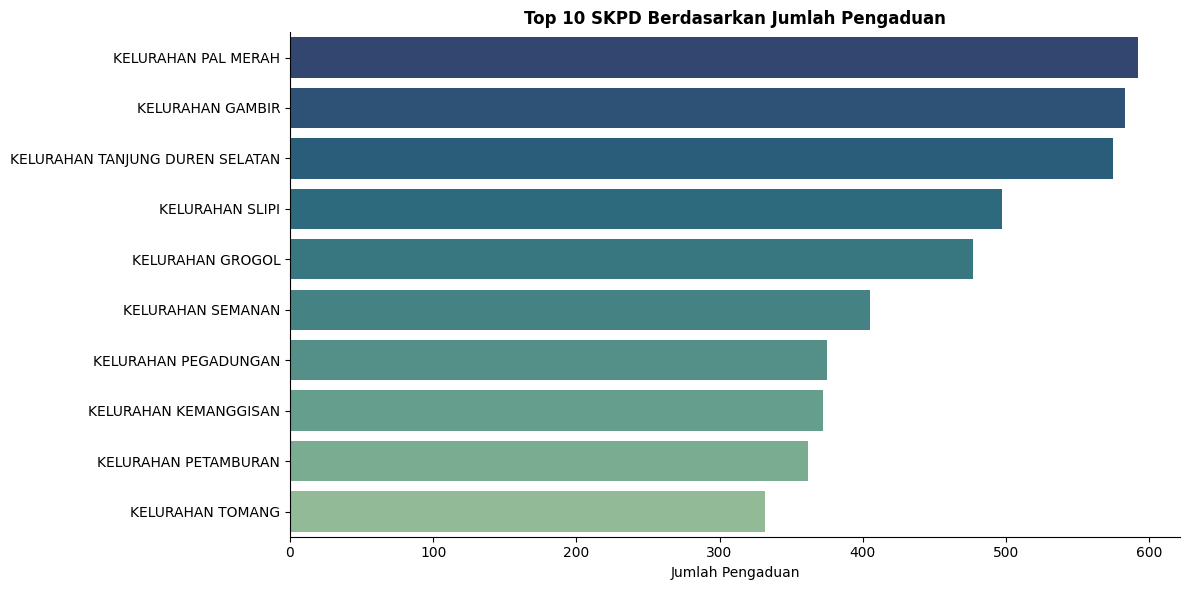

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_skpd, x='jumlah', y='skpd',
            palette='crest_r', hue='skpd', legend=False)
plt.title('Top 10 SKPD Berdasarkan Jumlah Pengaduan', fontweight='bold')
plt.xlabel('Jumlah Pengaduan')
plt.ylabel('')
sns.despine()
plt.tight_layout()
plt.show()

- Kategori Response Time berdasarkan Kategori

In [ ]:
# Data
resp_kategori = (df_clean[df_clean['response_time'] > 0]
                 .groupby('kategori')['response_time']
                 .agg(['mean', 'count'])
                 .reset_index())
resp_kategori.columns = ['kategori', 'avg_response', 'jumlah']
resp_kategori = resp_kategori[resp_kategori['jumlah'] >= 10]
resp_kategori['avg_response'] = resp_kategori['avg_response'].round(1)

top_lambat = resp_kategori.nlargest(10, 'avg_response').sort_values('avg_response')
print(top_lambat.to_string(index=False))

                                         kategori  avg_response  jumlah
                                            POHON           3.1      65
             GANGGUAN KETENTERAMAN DAN KETERTIBAN           3.5     143
                                           BANJIR           3.6      42
                                          TROTOAR           3.6      14
JEMBATAN PENYEBERANGAN ORANG (JPO) DAN/ATAU HALTE           4.7      80
                         PELANGGARAN PERDA/PERGUB           5.0     117
                                           SAMPAH           6.0     960
                                   BANTUAN SOSIAL           8.6      40
                                      SALURAN AIR          16.1      69
               LOKASI BINAAN DAN LOKASI SEMENTARA          27.7      10


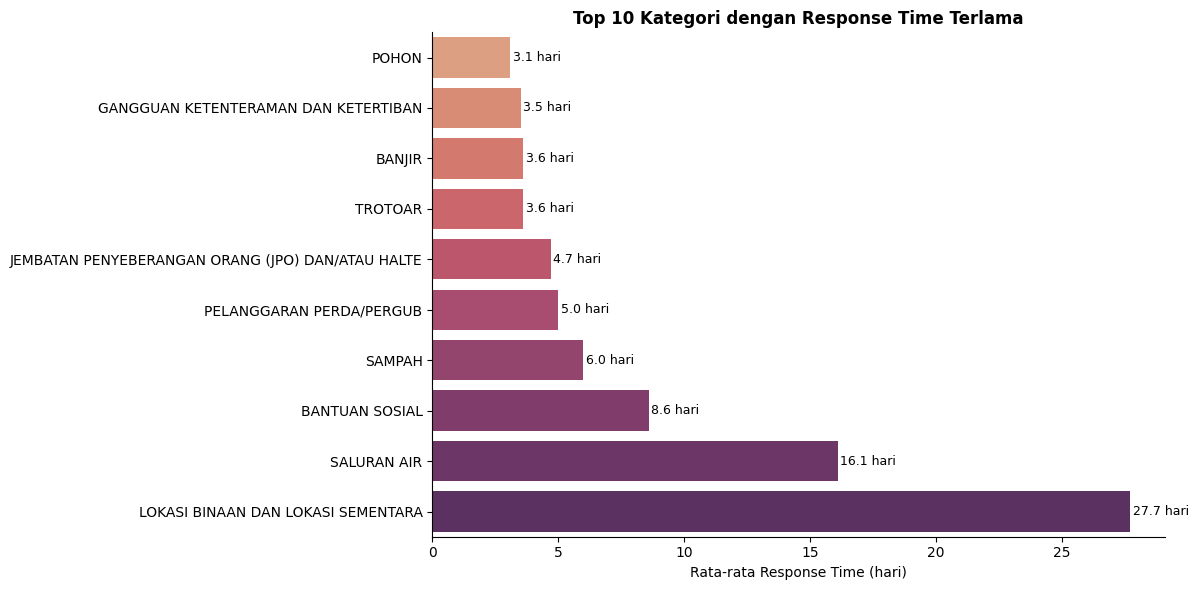

In [ ]:
# Visualisasi
plt.figure(figsize=(12, 6))
sns.barplot(data=top_lambat, x='avg_response', y='kategori',
            palette='flare', hue='kategori', legend=False)
plt.title('Top 10 Kategori dengan Response Time Terlama', fontweight='bold')
plt.xlabel('Rata-rata Response Time (hari)')
plt.ylabel('')
for i, row in enumerate(top_lambat.itertuples()):
    plt.text(row.avg_response + 0.1, i, f'{row.avg_response} hari', va='center', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# Data — ambil top 8 kategori supaya heatmap tidak terlalu padat
top8_kat = df_clean['kategori'].value_counts().head(8).index.tolist()

df_heatmap = df_clean[df_clean['kategori'].isin(top8_kat)].copy()
df_heatmap['nama_bulan'] = df_heatmap['tanggal_masuk'].dt.month_name()

bulan_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

pivot = (df_heatmap.groupby(['nama_bulan', 'kategori'])
                   .size()
                   .reset_index(name='jumlah')
                   .pivot(index='nama_bulan', columns='kategori', values='jumlah')
                   .fillna(0))

pivot = pivot.reindex(bulan_order)
print(pivot)

kategori    BANJIR  GANGGUAN KETENTERAMAN DAN KETERTIBAN  \
nama_bulan                                                 
January       93.0                                  30.0   
February     133.0                                  62.0   
March         16.0                                  18.0   
April         12.0                                 102.0   
May           11.0                                  20.0   
June           4.0                                 136.0   
July           1.0                                  87.0   
August         9.0                                  90.0   
September      5.0                                  83.0   
October        0.0                                  82.0   
November       0.0                                  96.0   
December       0.0                                  37.0   

kategori    JEMBATAN PENYEBERANGAN ORANG (JPO) DAN/ATAU HALTE  \
nama_bulan                                                      
January                      

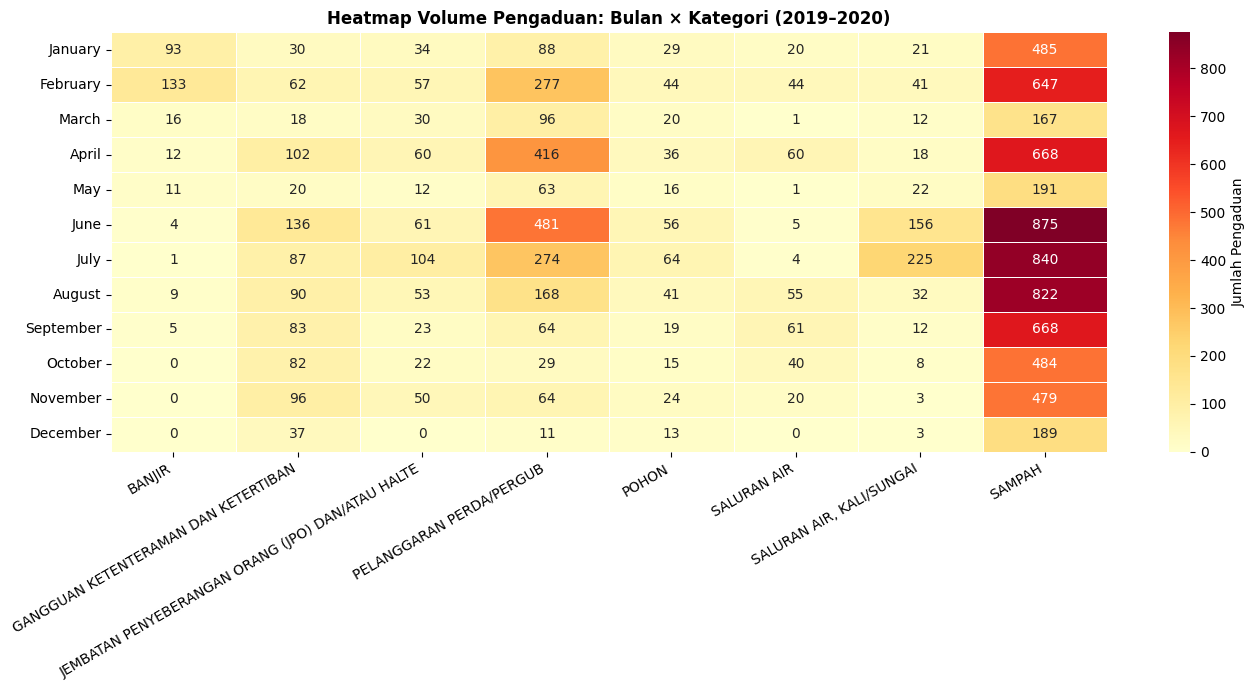

In [ ]:
# Visualisasi
plt.figure(figsize=(14, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Jumlah Pengaduan'})
plt.title('Heatmap Volume Pengaduan: Bulan × Kategori (2019–2020)', fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()